In [2]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
insurance_data=pd.read_csv("insurance.csv")

X=insurance_data.drop(columns=["charges"])
Y=insurance_data["charges"]
X=pd.get_dummies(X,columns=["region"],drop_first=True,dtype=int)
X["sex"]=X["sex"].map({"female":1,"male":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})
X["age_smoker"]=X["age"] * X["smoker"]
X["bmi_smoker"]=X["bmi"]*X["smoker"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)


Mse for 0.001: 20922599.871035974
Mse for 0.1: 20921803.69843139
Mse for 1: 20914832.635089148
Mse for 2: 20908106.779954527
Mse for 5: 20890881.000633504
Mse for 10: 20872844.794796687
Mse for 20: 20877828.53237883
Mse for 30: 20937537.13393977
Mse for 40: 21046489.293890774
Mse for 50: 21196929.869608898
Mse for 100: 22423172.68602322


<Axes: >

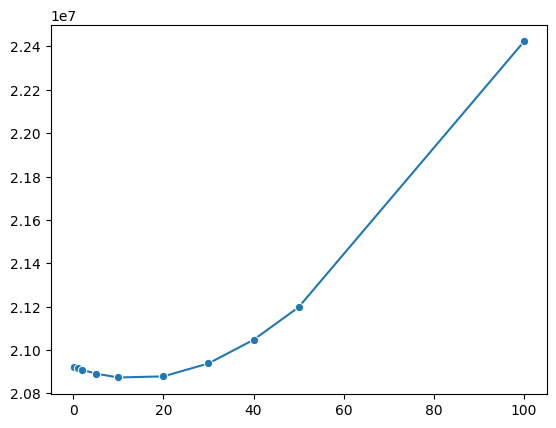

In [16]:
import seaborn as sns
alphas=[0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
mses=[]
for a in alphas: 
    lasso_model=Lasso(alpha=a)
    lasso_model.fit(X_train,Y_train)
    Y_pred=lasso_model.predict(X_test)
    mse=mean_squared_error(Y_test,Y_pred)
    print(f"Mse for {a}:",mse)
    mses.append(mse)
sns.lineplot(x=alphas,y=mses,marker="o")
    

In [23]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score
a=[0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
Lasso_cv_model= LassoCV(
    alphas=a,
    cv=5,
    max_iter=10000,
    random_state=42
)
Lasso_cv_model.fit(X_train,Y_train)
Y_pred=Lasso_cv_model.predict(X_test)
mse=mean_squared_error(Y_test,Y_pred)
r2_test=r2_score(Y_test, Y_pred)
print("MSE:", mse)
print("R2 Score:",r2_test)
print("Best alpha value:",Lasso_cv_model.alpha_)

MSE: 20922599.871035974
R2 Score: 0.8652317499151698
Best alpha value: 0.001


In [ ]:
l1=